# TM vs Infomap: discovery sample

Network names and colours are independent between methods: similar colours do **not** imply corresponding networks. No network crosswalk or overlap metric is computed. Only cortex is shown.

TM 0/4/6/17 and Infomap 0 are masked. Percentages include all cortical vertices in the CIFTI, including masked/unassigned vertices, and exclude the medial wall. TM has its own legend; the two Infomap rows share one legend (same label table) listing displayed networks present in either, with statistics given as filtered + dilated / unfiltered. Black TM Salience remains black on a light surface background.

Use the **pypfm (group env)** kernel in a Sherlock compute allocation (`sh_dev` or the current Open OnDemand compute session). Rendering uses one CPU and a few GB of memory; allow several minutes for the full batch. All input files are read-only.


## 1. Settings

In [1]:
from pathlib import Path
import os
import sys

# Open from code/ or code/tm_vs_infomap/.
HERE = Path.cwd()
MODULE_DIR = HERE if (HERE / "tm_vs_infomap.py").is_file() else HERE / "tm_vs_infomap"
if not (MODULE_DIR / "tm_vs_infomap.py").is_file():
    raise FileNotFoundError("Open this notebook from code/ or code/tm_vs_infomap/.")
sys.path.insert(0, str(MODULE_DIR))
import matplotlib.pyplot as plt
from IPython.display import display
import importlib
import tm_vs_infomap
importlib.reload(tm_vs_infomap)
from tm_vs_infomap import (
    Settings, default_project, input_inventory, require_inputs,
    load_case, coverage_table, plot_case, save_case,
)

PROJECT = default_project()  # Or an explicit Path to pfm_compare.
SETTINGS = Settings(
    project=PROJECT,
    run_label="discovery-100trials-seed42-blas",
    post_label="area50mm2-dil50mm",
    tm_unlabelled="mask",  # Mask 0, 4, 6, 17, matching the overlap notebooks.
    legend_stats="percent",  # Alternatives: "count", "none".
    dpi=150,
    include_unfiltered=True,  # Add regular Infomap (no spatial filter or dilation).
)
OUTPUT_DIR = PROJECT / "analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered"
OVERWRITE = True  # Set True deliberately when rerunning saved figures.

SUBJECTS = ["s03", "s10", "s19", "s29", "s43"]
CONDITIONS = ["rest", "task"]


## 2. Check all dependencies

Ten cases require 60 file references: 30 network maps, 10 TM companion dlabels, and 20 surface references (10 unique surfaces). Nothing is silently skipped.

In [2]:
inventory = input_inventory(SETTINGS, SUBJECTS, CONDITIONS)
display(inventory)
print(f"{inventory.exists.sum()}/{len(inventory)} file references found")
require_inputs(inventory)


,subject,condition,role,path,exists
0,s03,rest,tm,/oak/stanford/groups/russpold/users/grimsrud/p...,True
1,s03,rest,tm_labels,/oak/stanford/groups/russpold/users/grimsrud/p...,True
2,s03,rest,infomap_unfiltered,/oak/stanford/groups/russpold/users/grimsrud/p...,True
3,s03,rest,infomap,/oak/stanford/groups/russpold/users/grimsrud/p...,True
4,s03,rest,surface_L,/oak/stanford/groups/russpold/users/grimsrud/p...,True
5,s03,rest,surface_R,/oak/stanford/groups/russpold/users/grimsrud/p...,True
6,s03,task,tm,/oak/stanford/groups/russpold/users/grimsrud/p...,True
7,s03,task,tm_labels,/oak/stanford/groups/russpold/users/grimsrud/p...,True
8,s03,task,infomap_unfiltered,/oak/stanford/groups/russpold/users/grimsrud/p...,True
9,s03,task,infomap,/oak/stanford/groups/russpold/users/grimsrud/p...,True


60/60 file references found


## 3. Validate every case before rendering

This checks the contents and cortical vertex order as well as existence.

In [3]:
for subject in SUBJECTS:
    for condition in CONDITIONS:
        case = load_case(SETTINGS, subject, condition)
        print(f"Validated sub-{subject} {condition}")


Validated sub-s03 rest
Validated sub-s03 task
Validated sub-s10 rest
Validated sub-s10 task
Validated sub-s19 rest
Validated sub-s19 task
Validated sub-s29 rest
Validated sub-s29 task
Validated sub-s43 rest
Validated sub-s43 task


## 4. Save and display all figures

Stops on invalid inputs or existing outputs. Use a new output folder for a separate run, or set `OVERWRITE=True` to regenerate deliberately. Figures are closed after display to limit memory use.

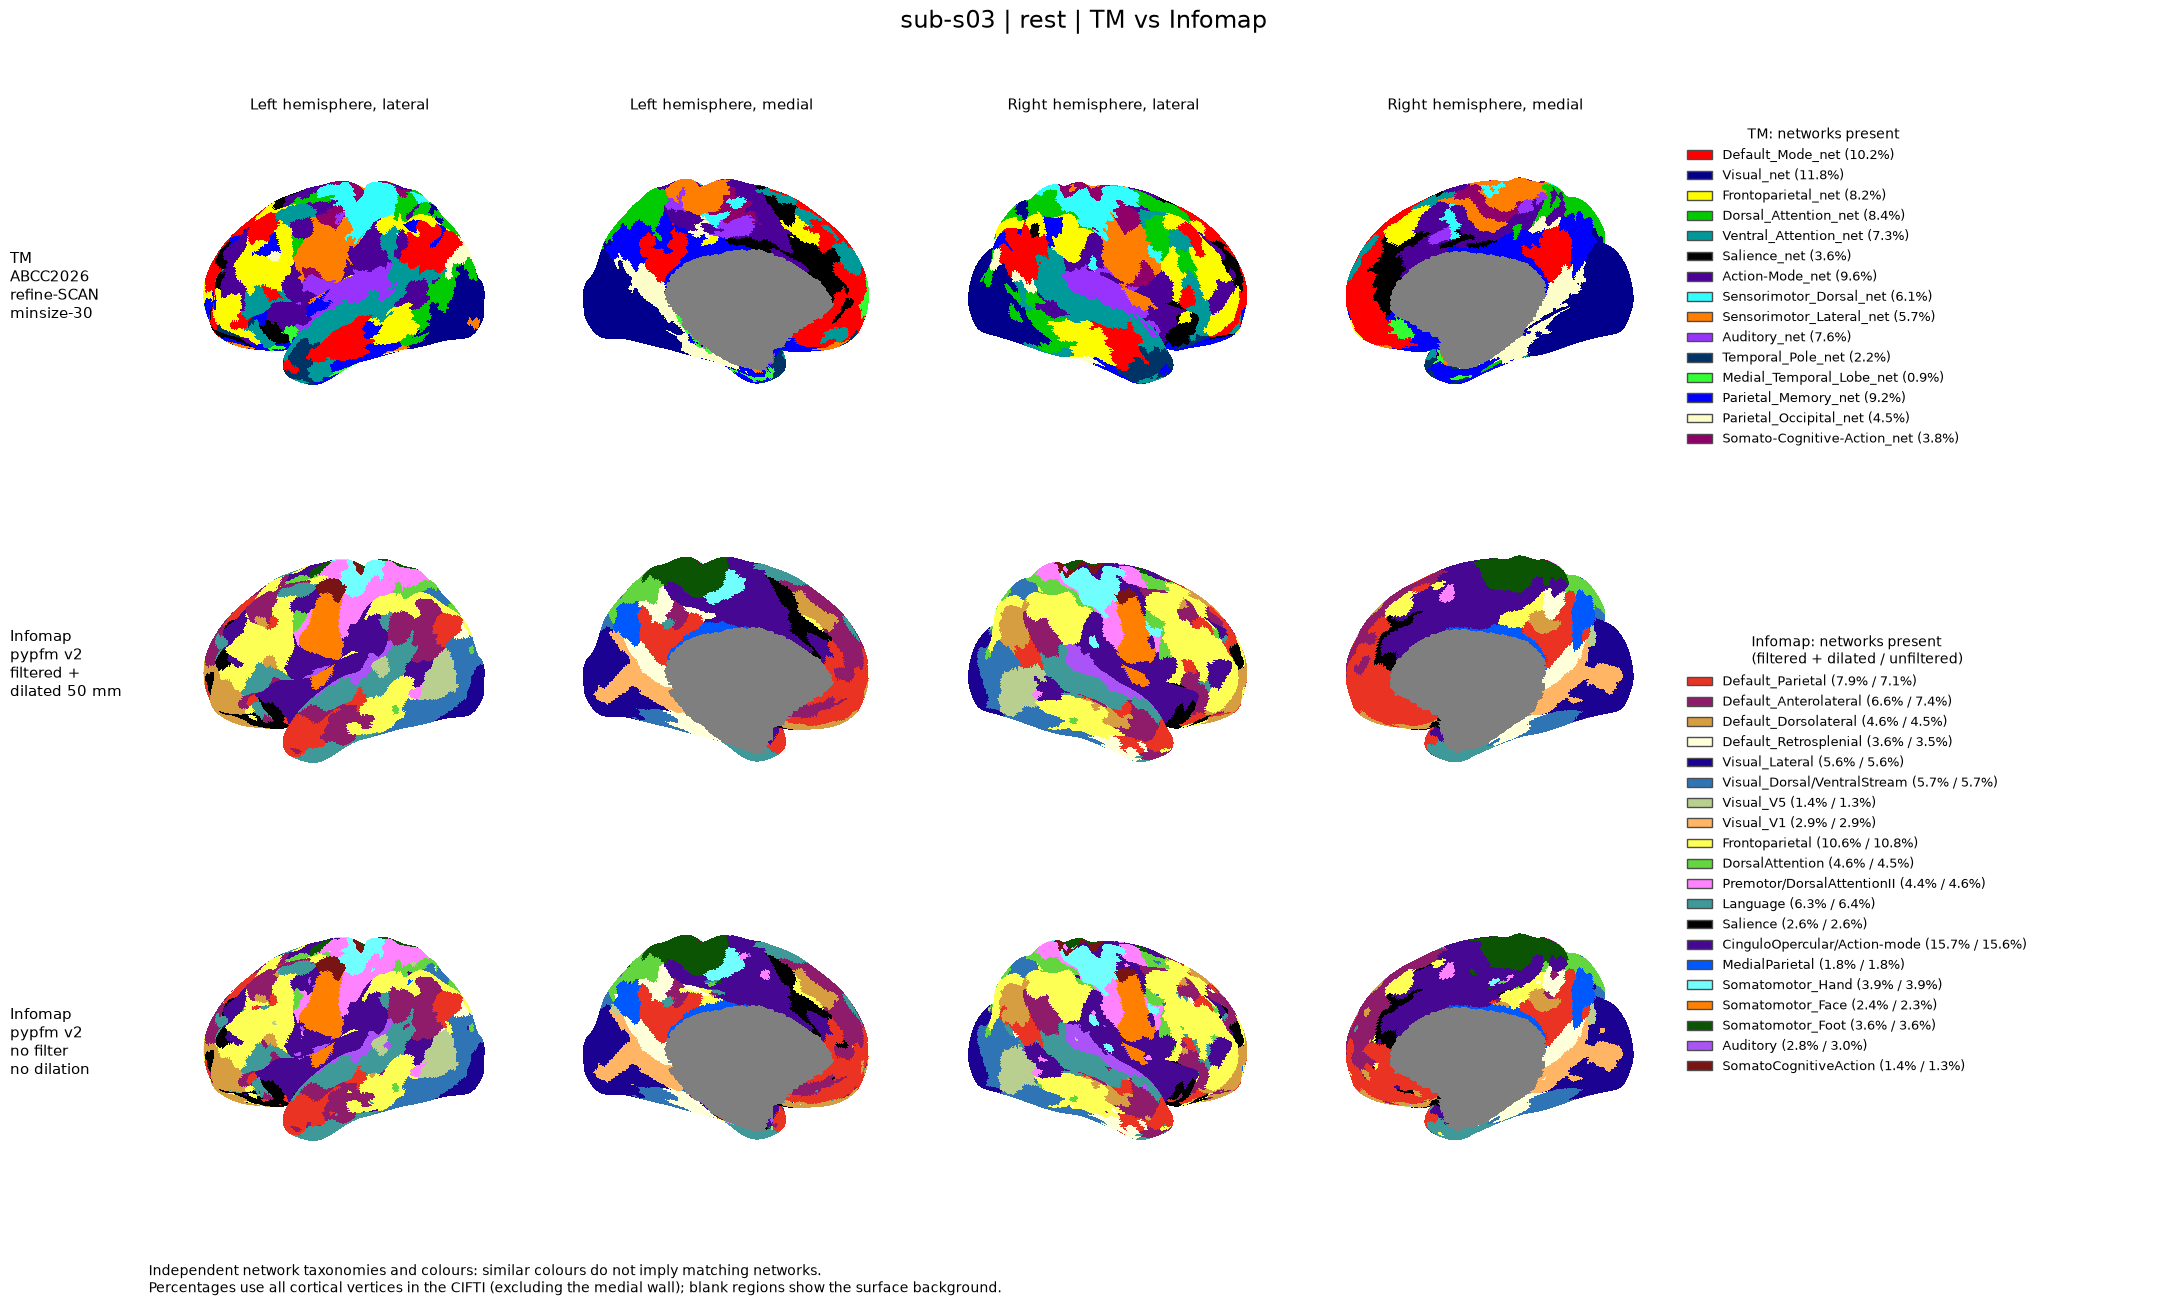

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s03_task-rest_TM-vs-Infomap.png


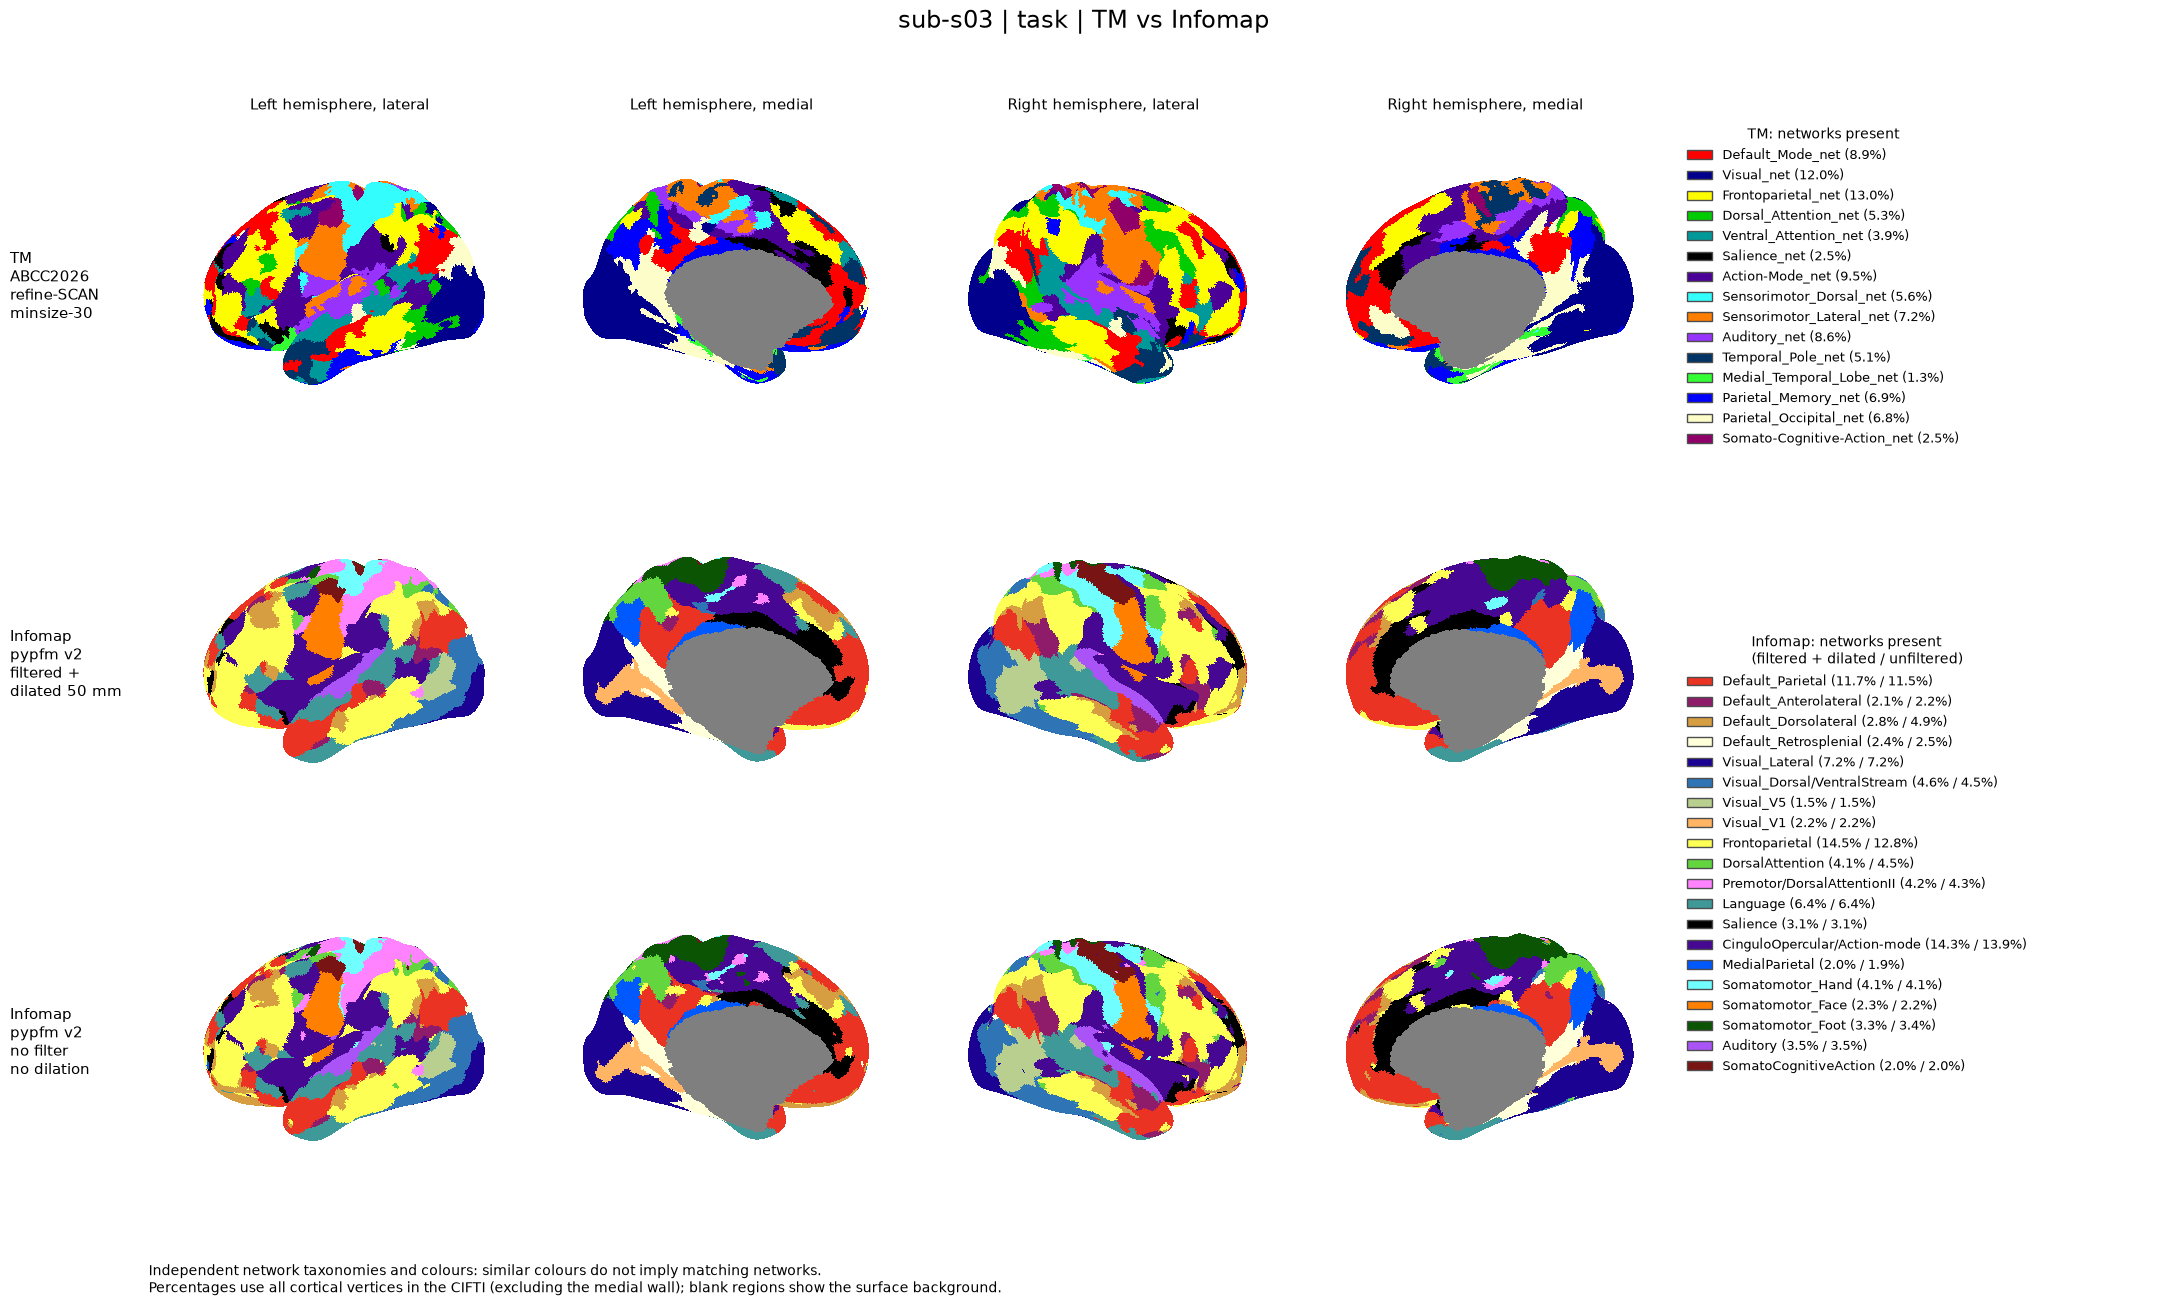

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s03_task-task_TM-vs-Infomap.png


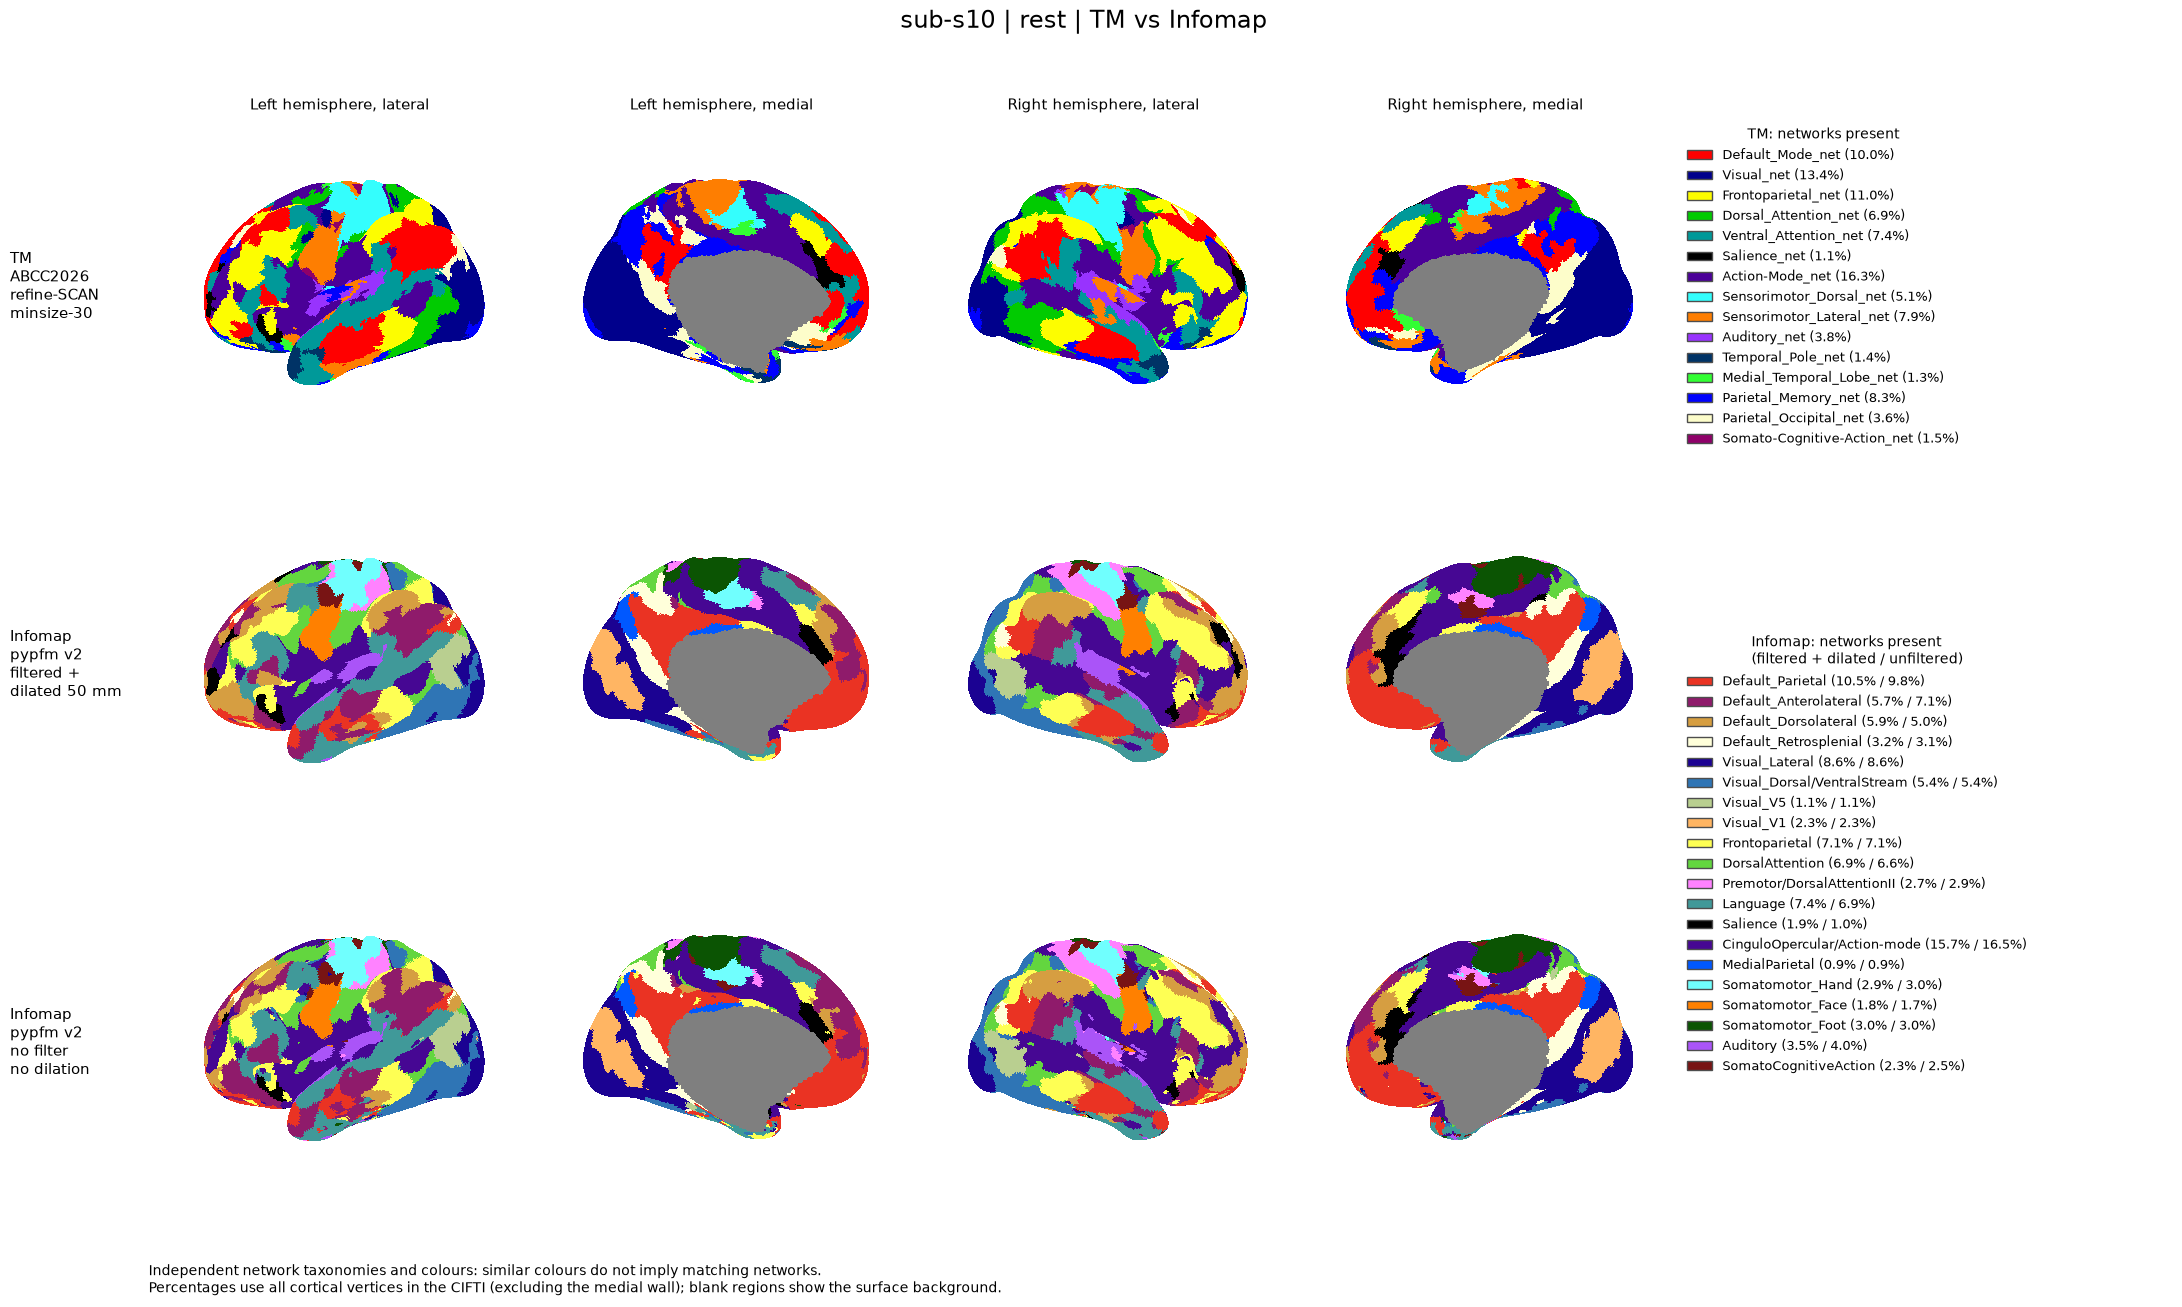

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s10_task-rest_TM-vs-Infomap.png


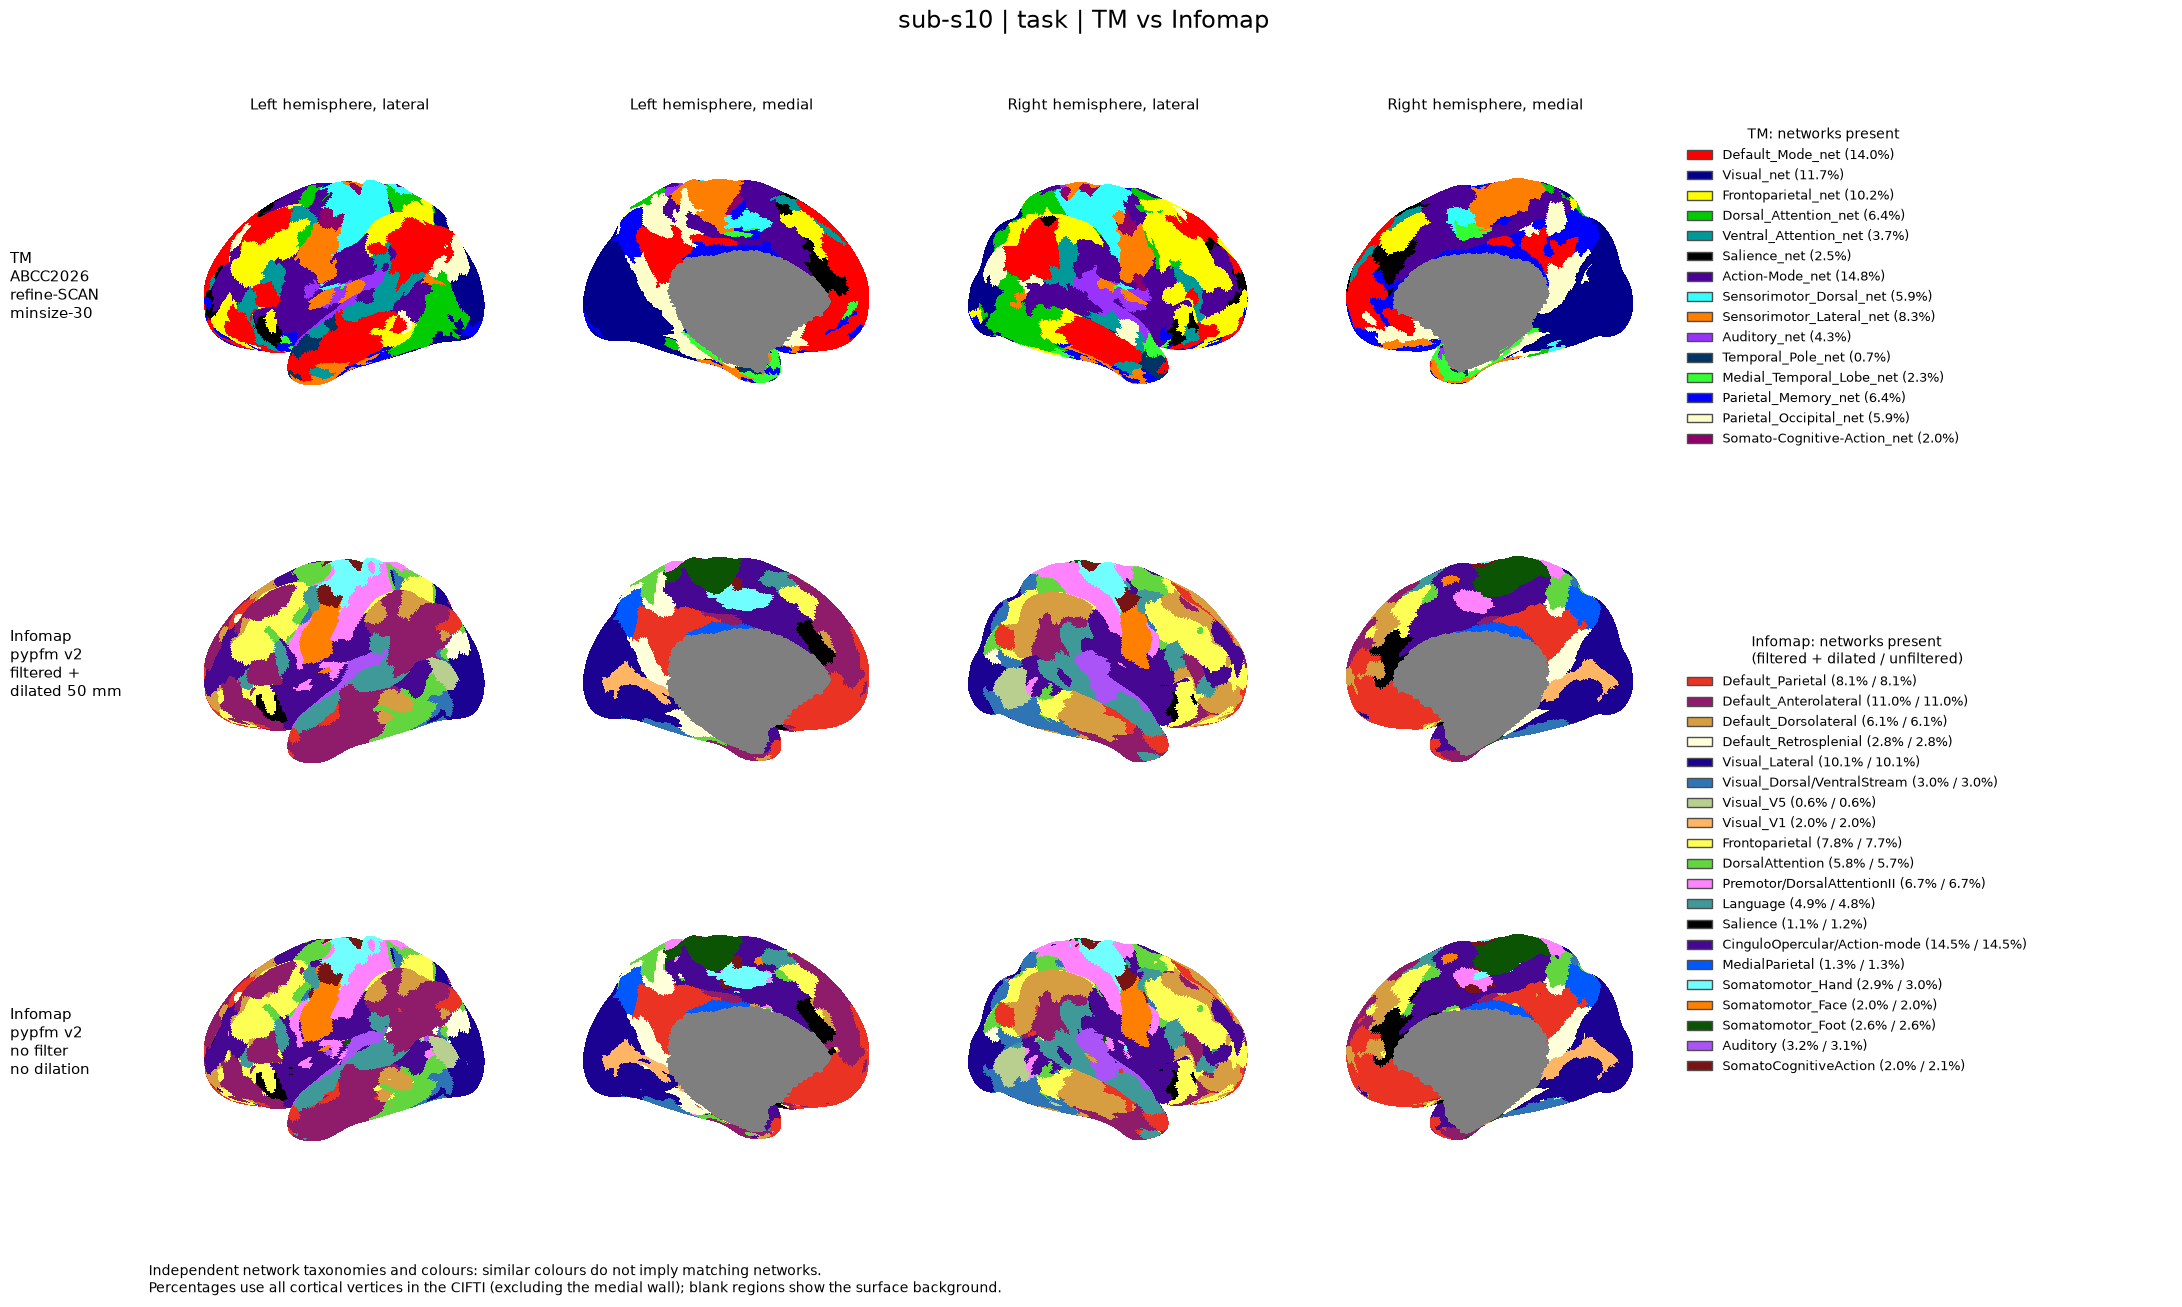

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s10_task-task_TM-vs-Infomap.png


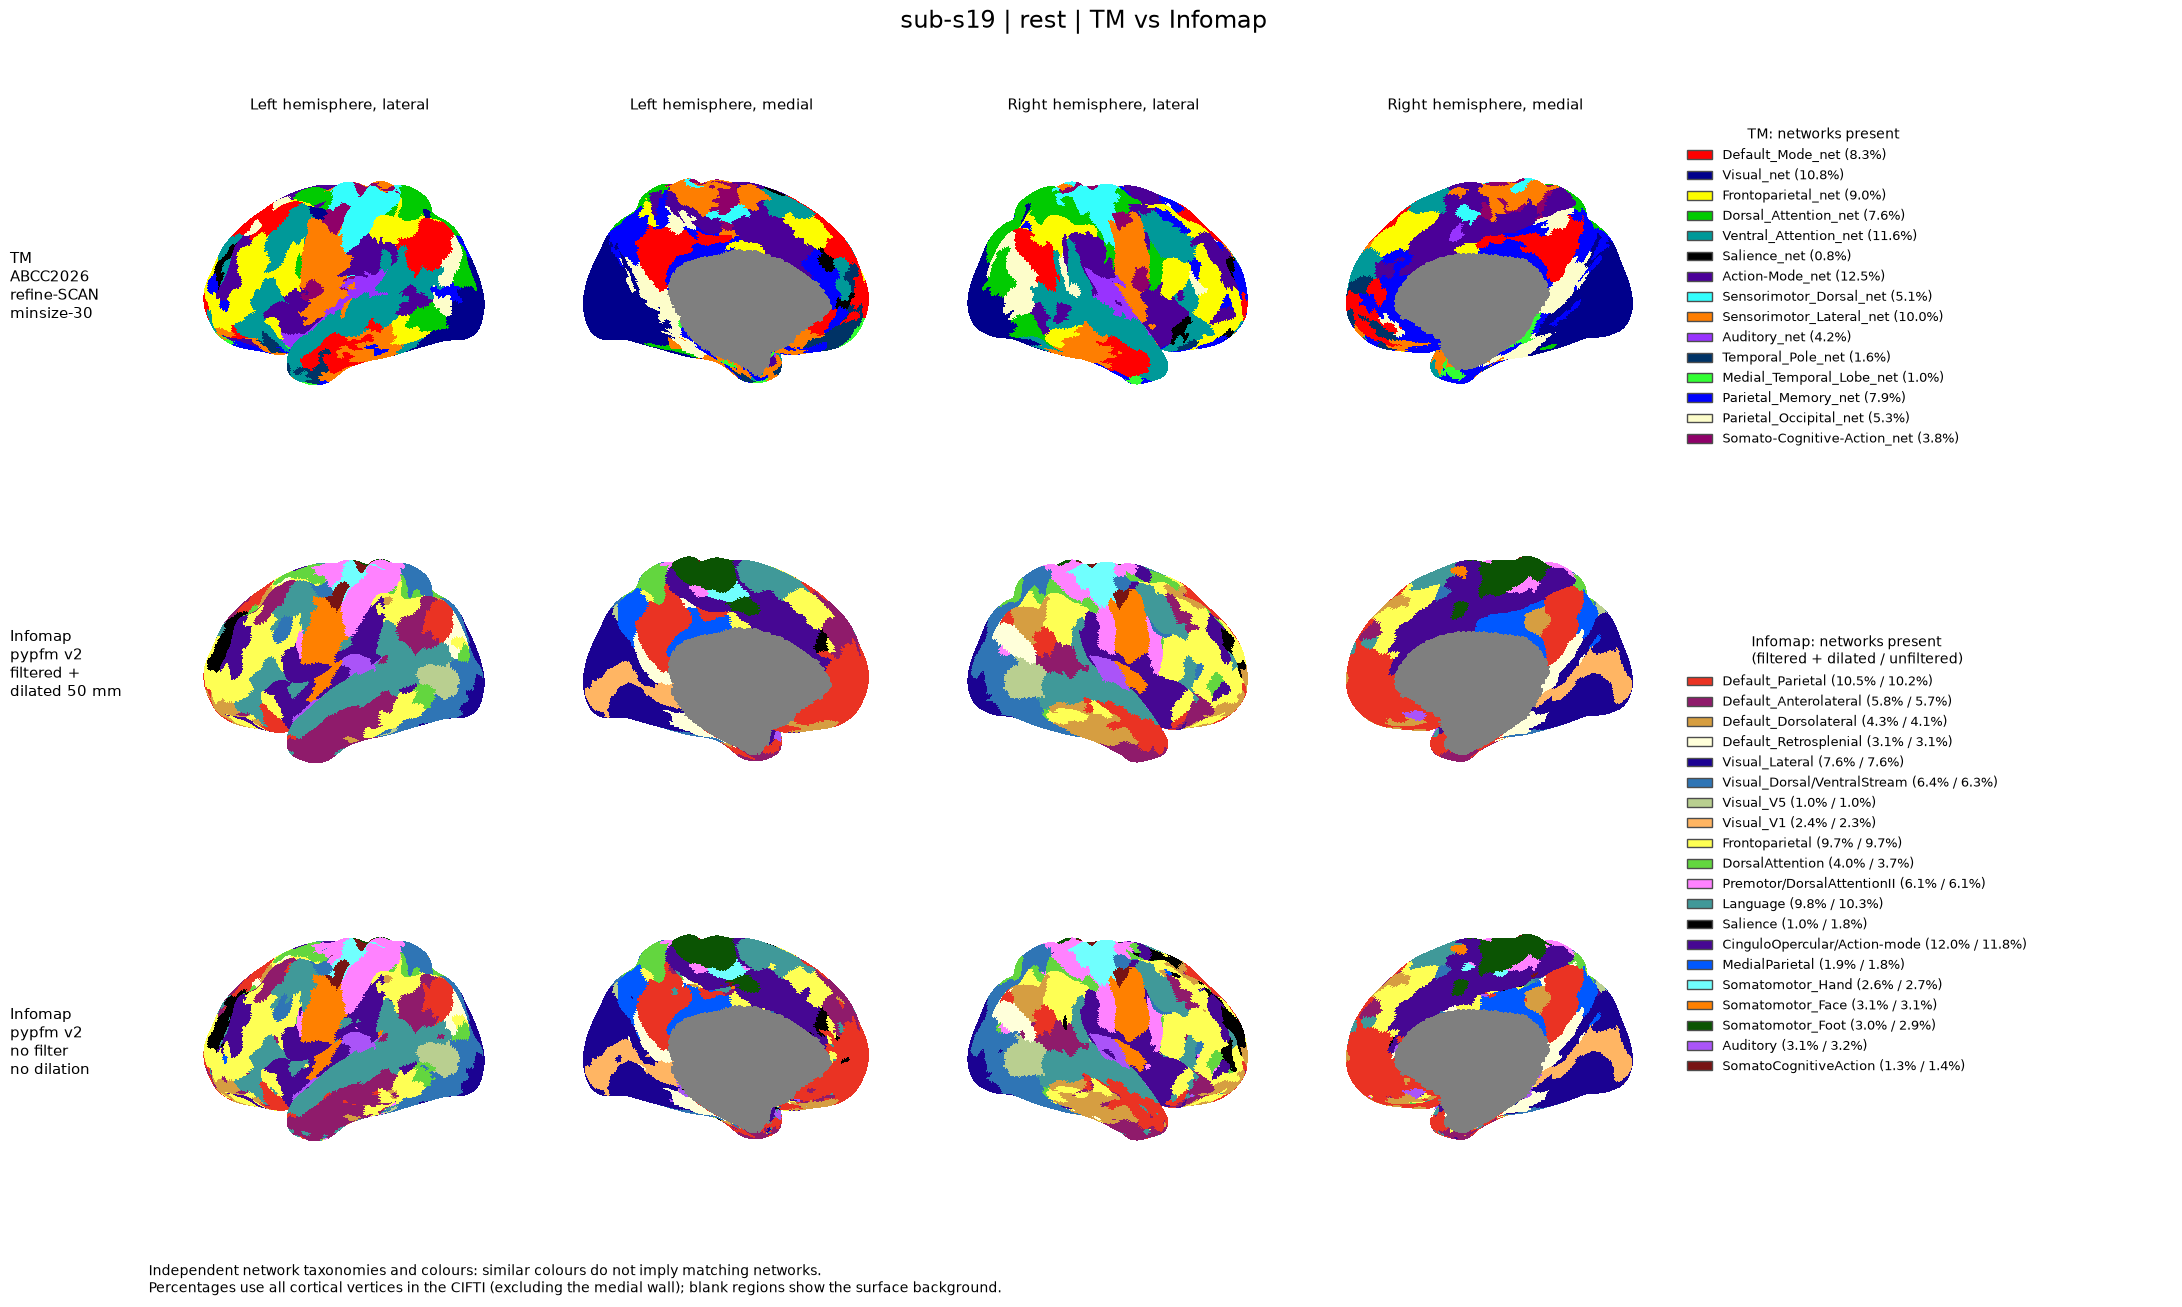

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s19_task-rest_TM-vs-Infomap.png


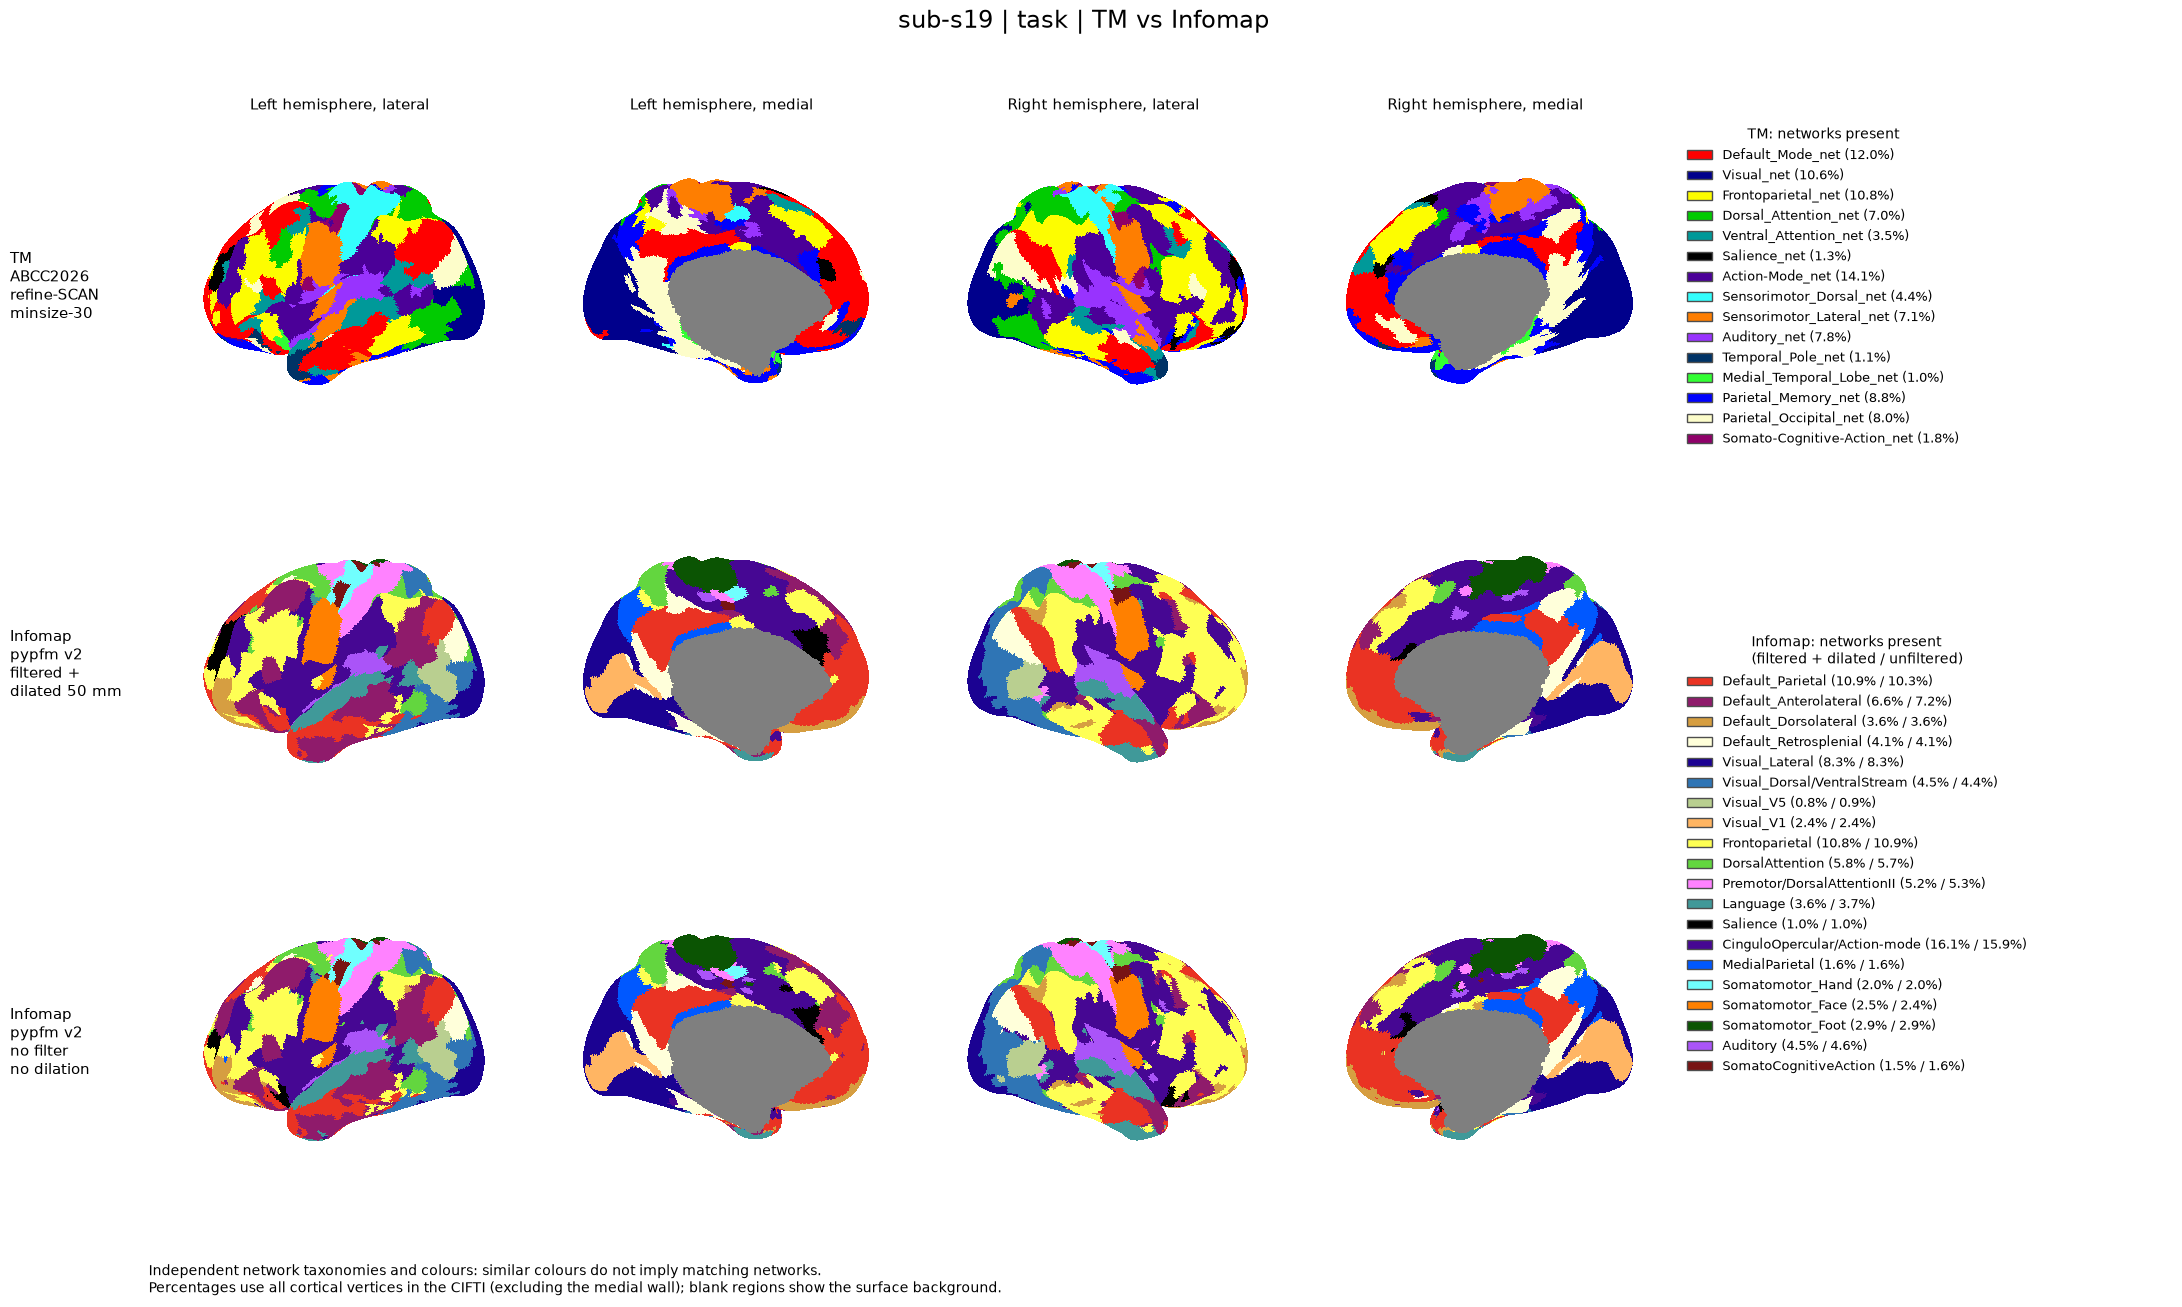

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s19_task-task_TM-vs-Infomap.png


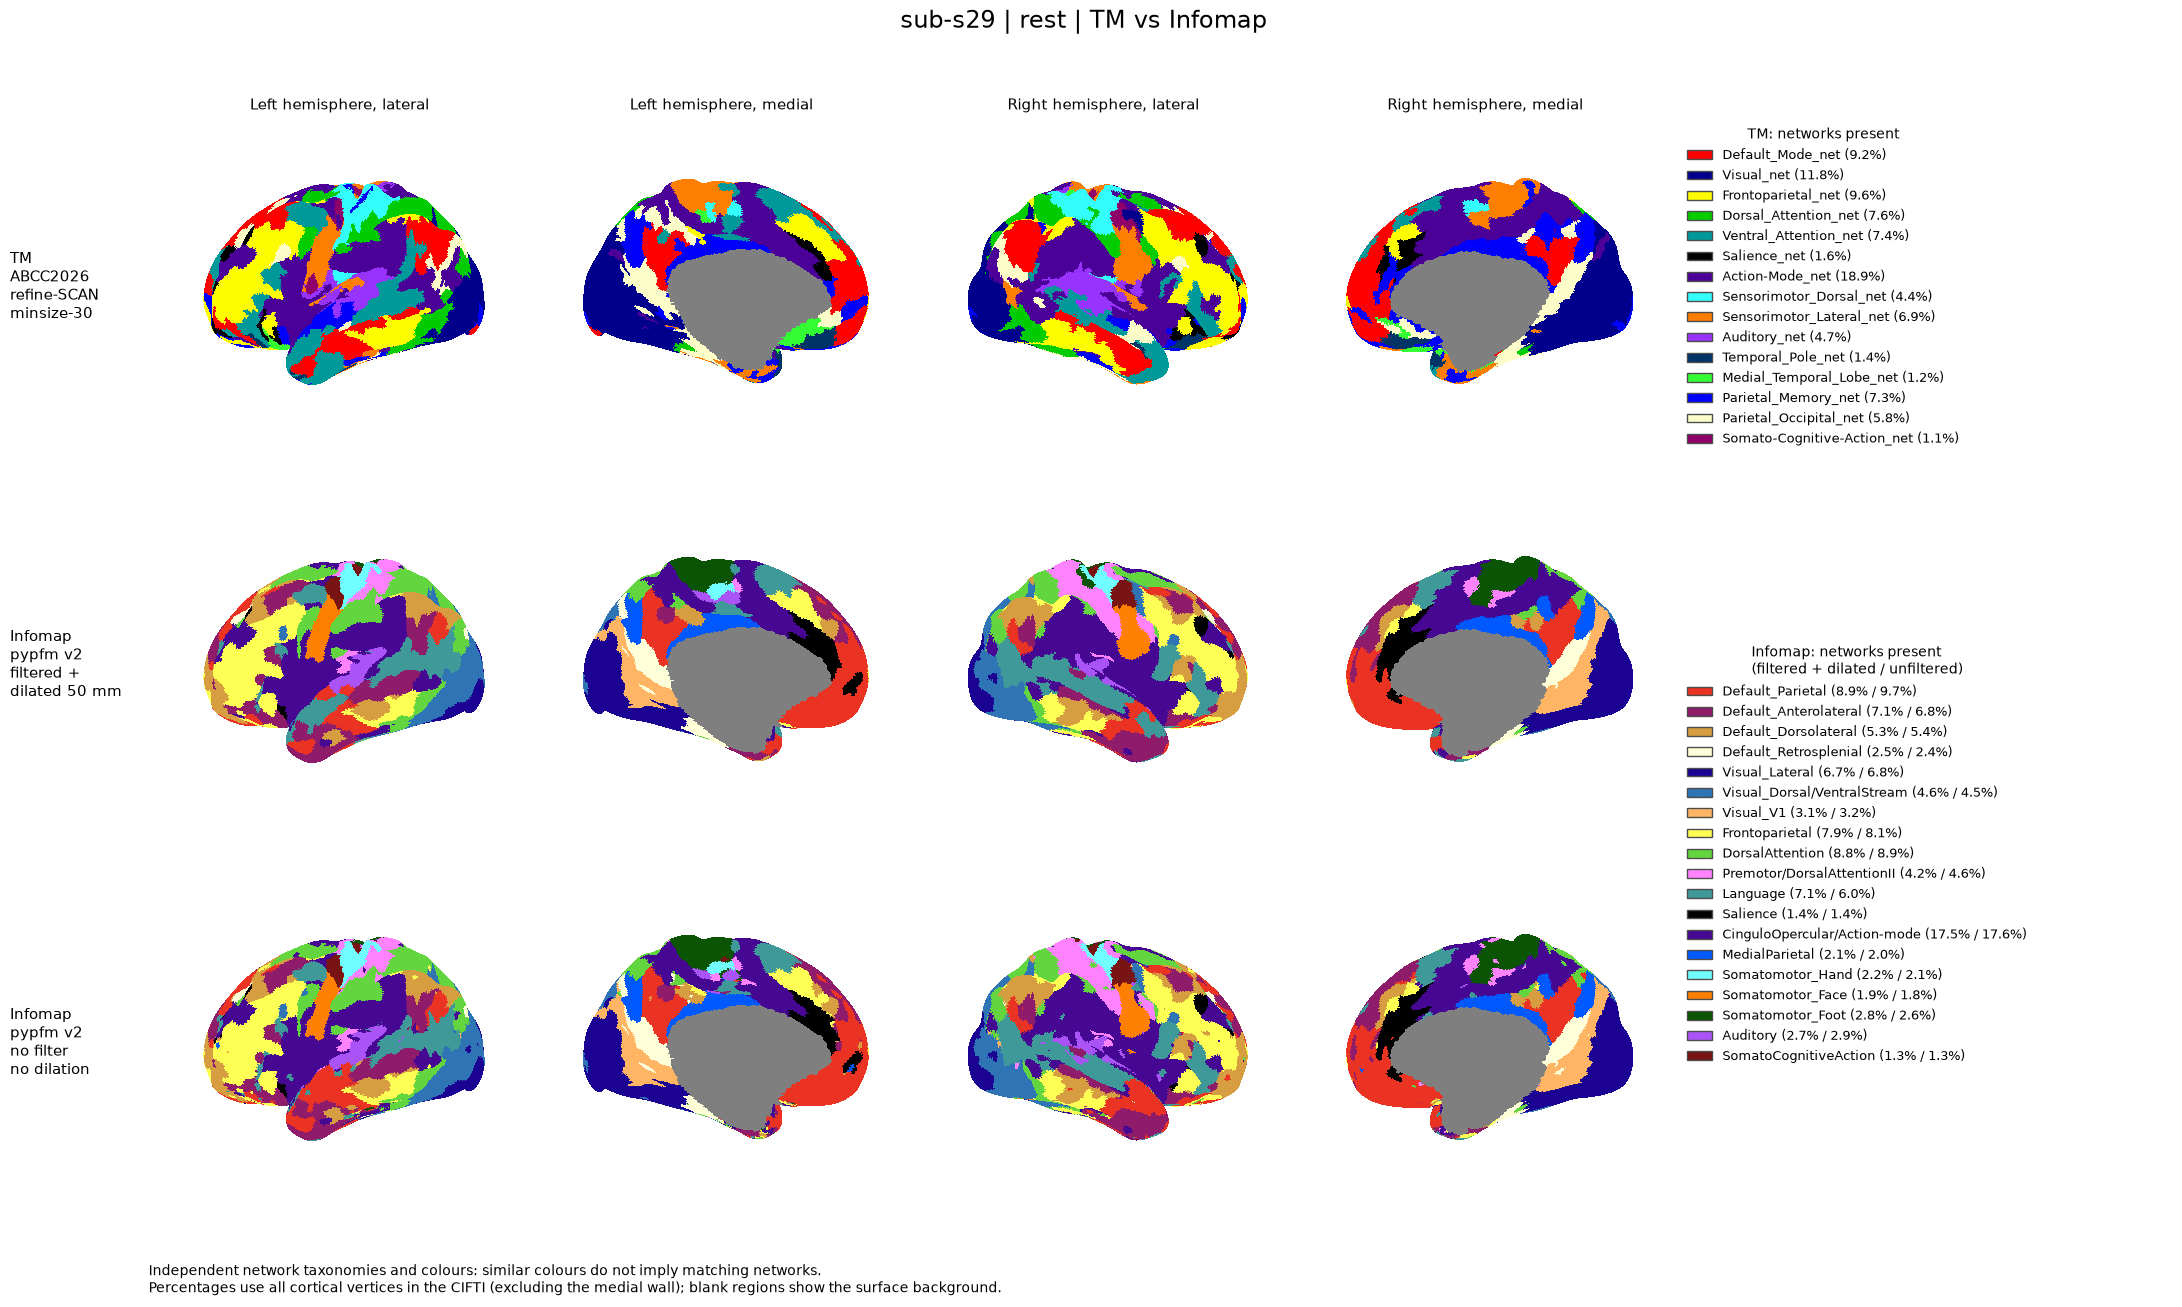

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s29_task-rest_TM-vs-Infomap.png


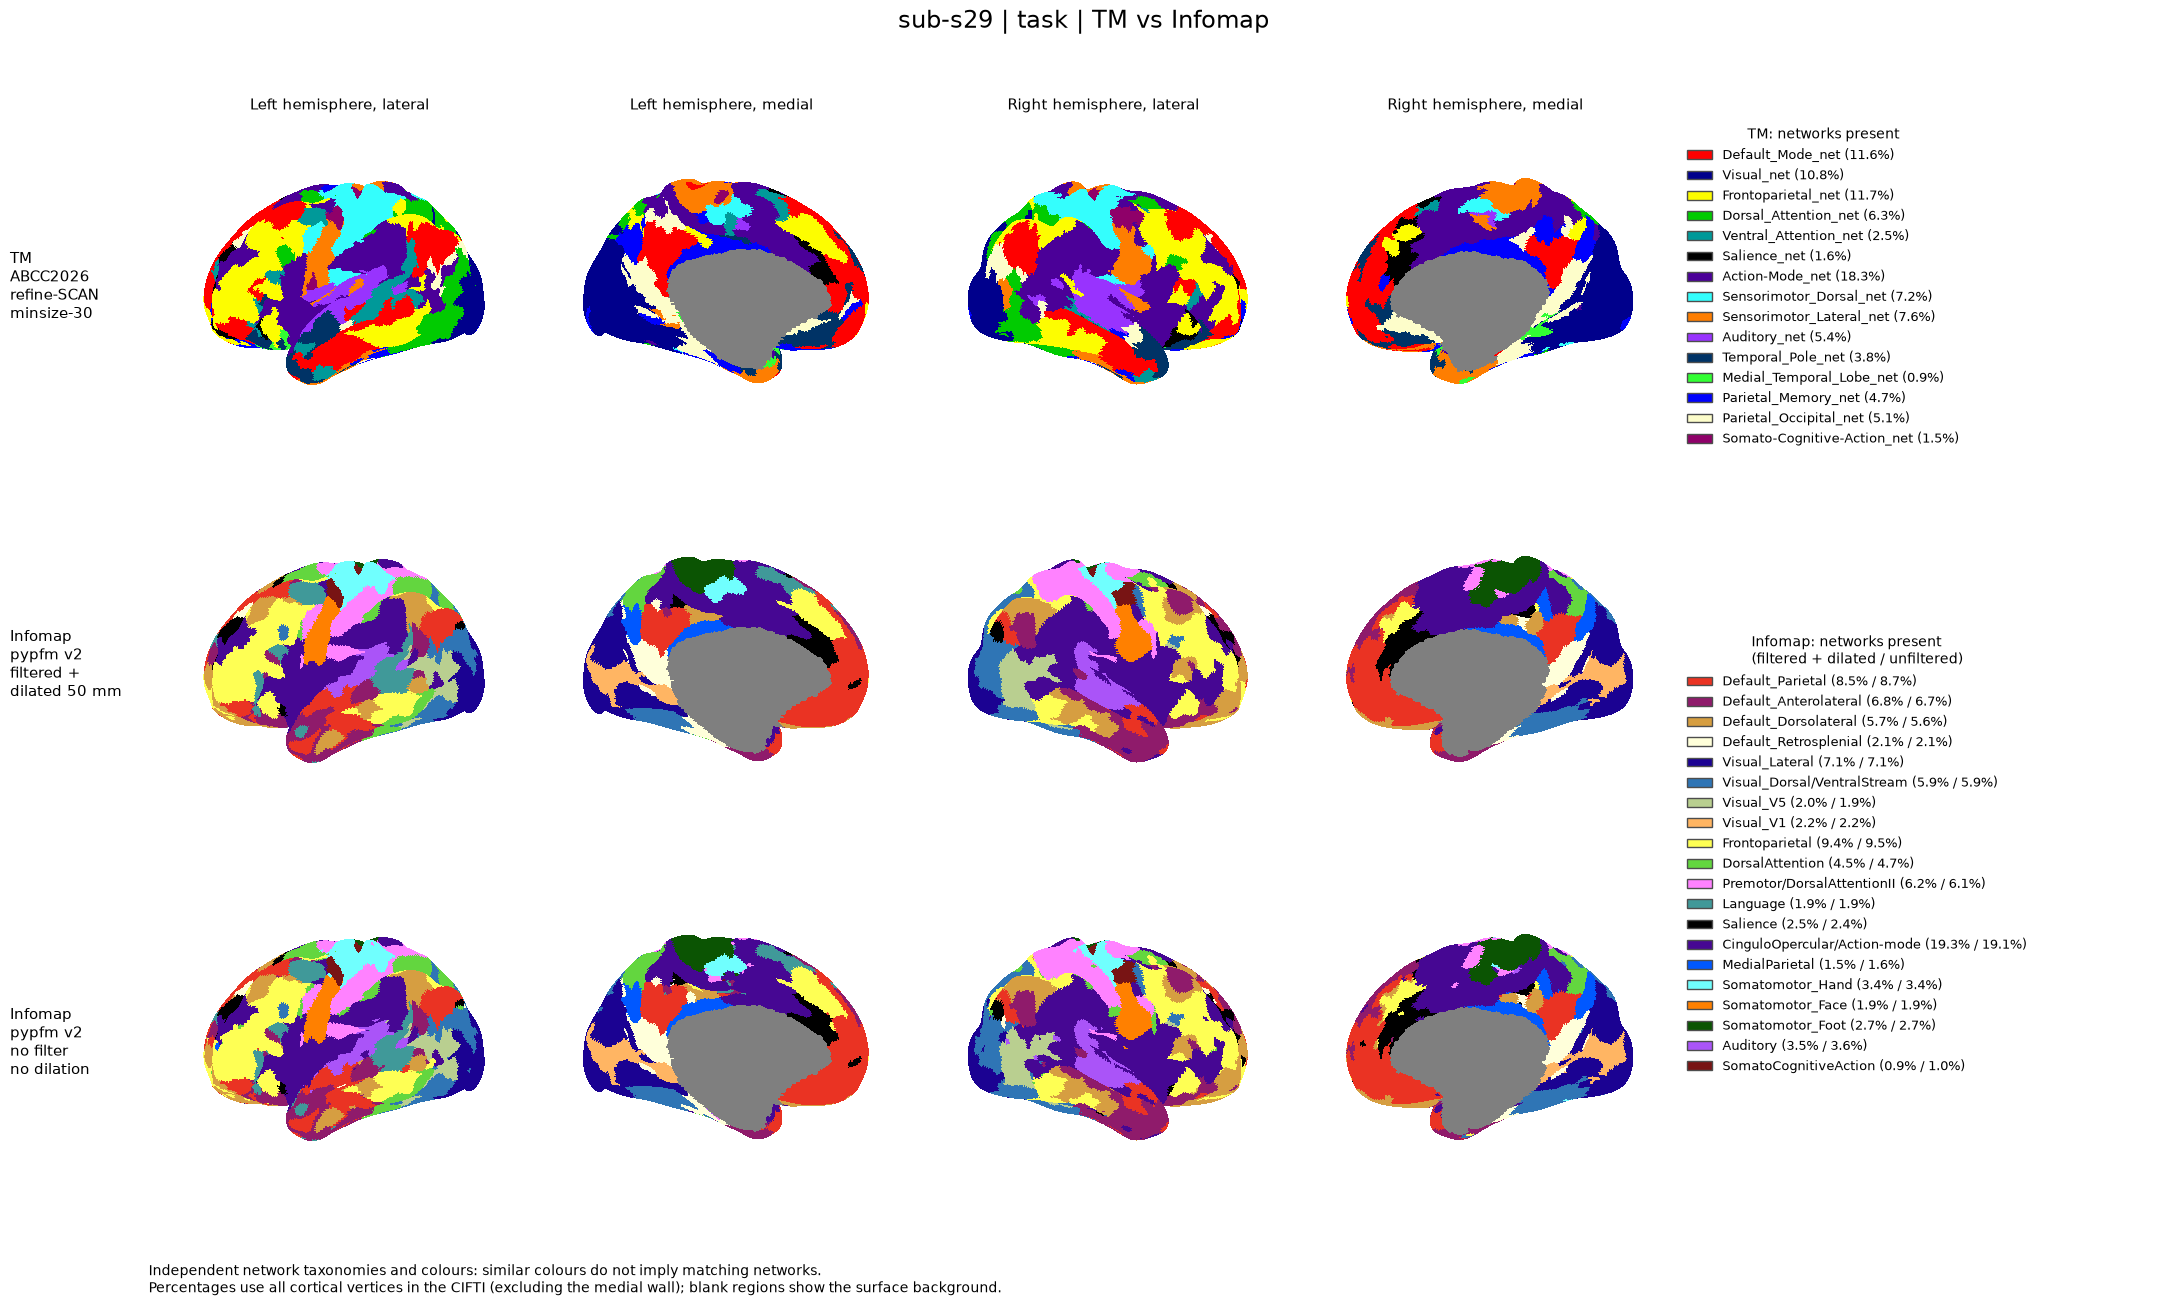

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s29_task-task_TM-vs-Infomap.png


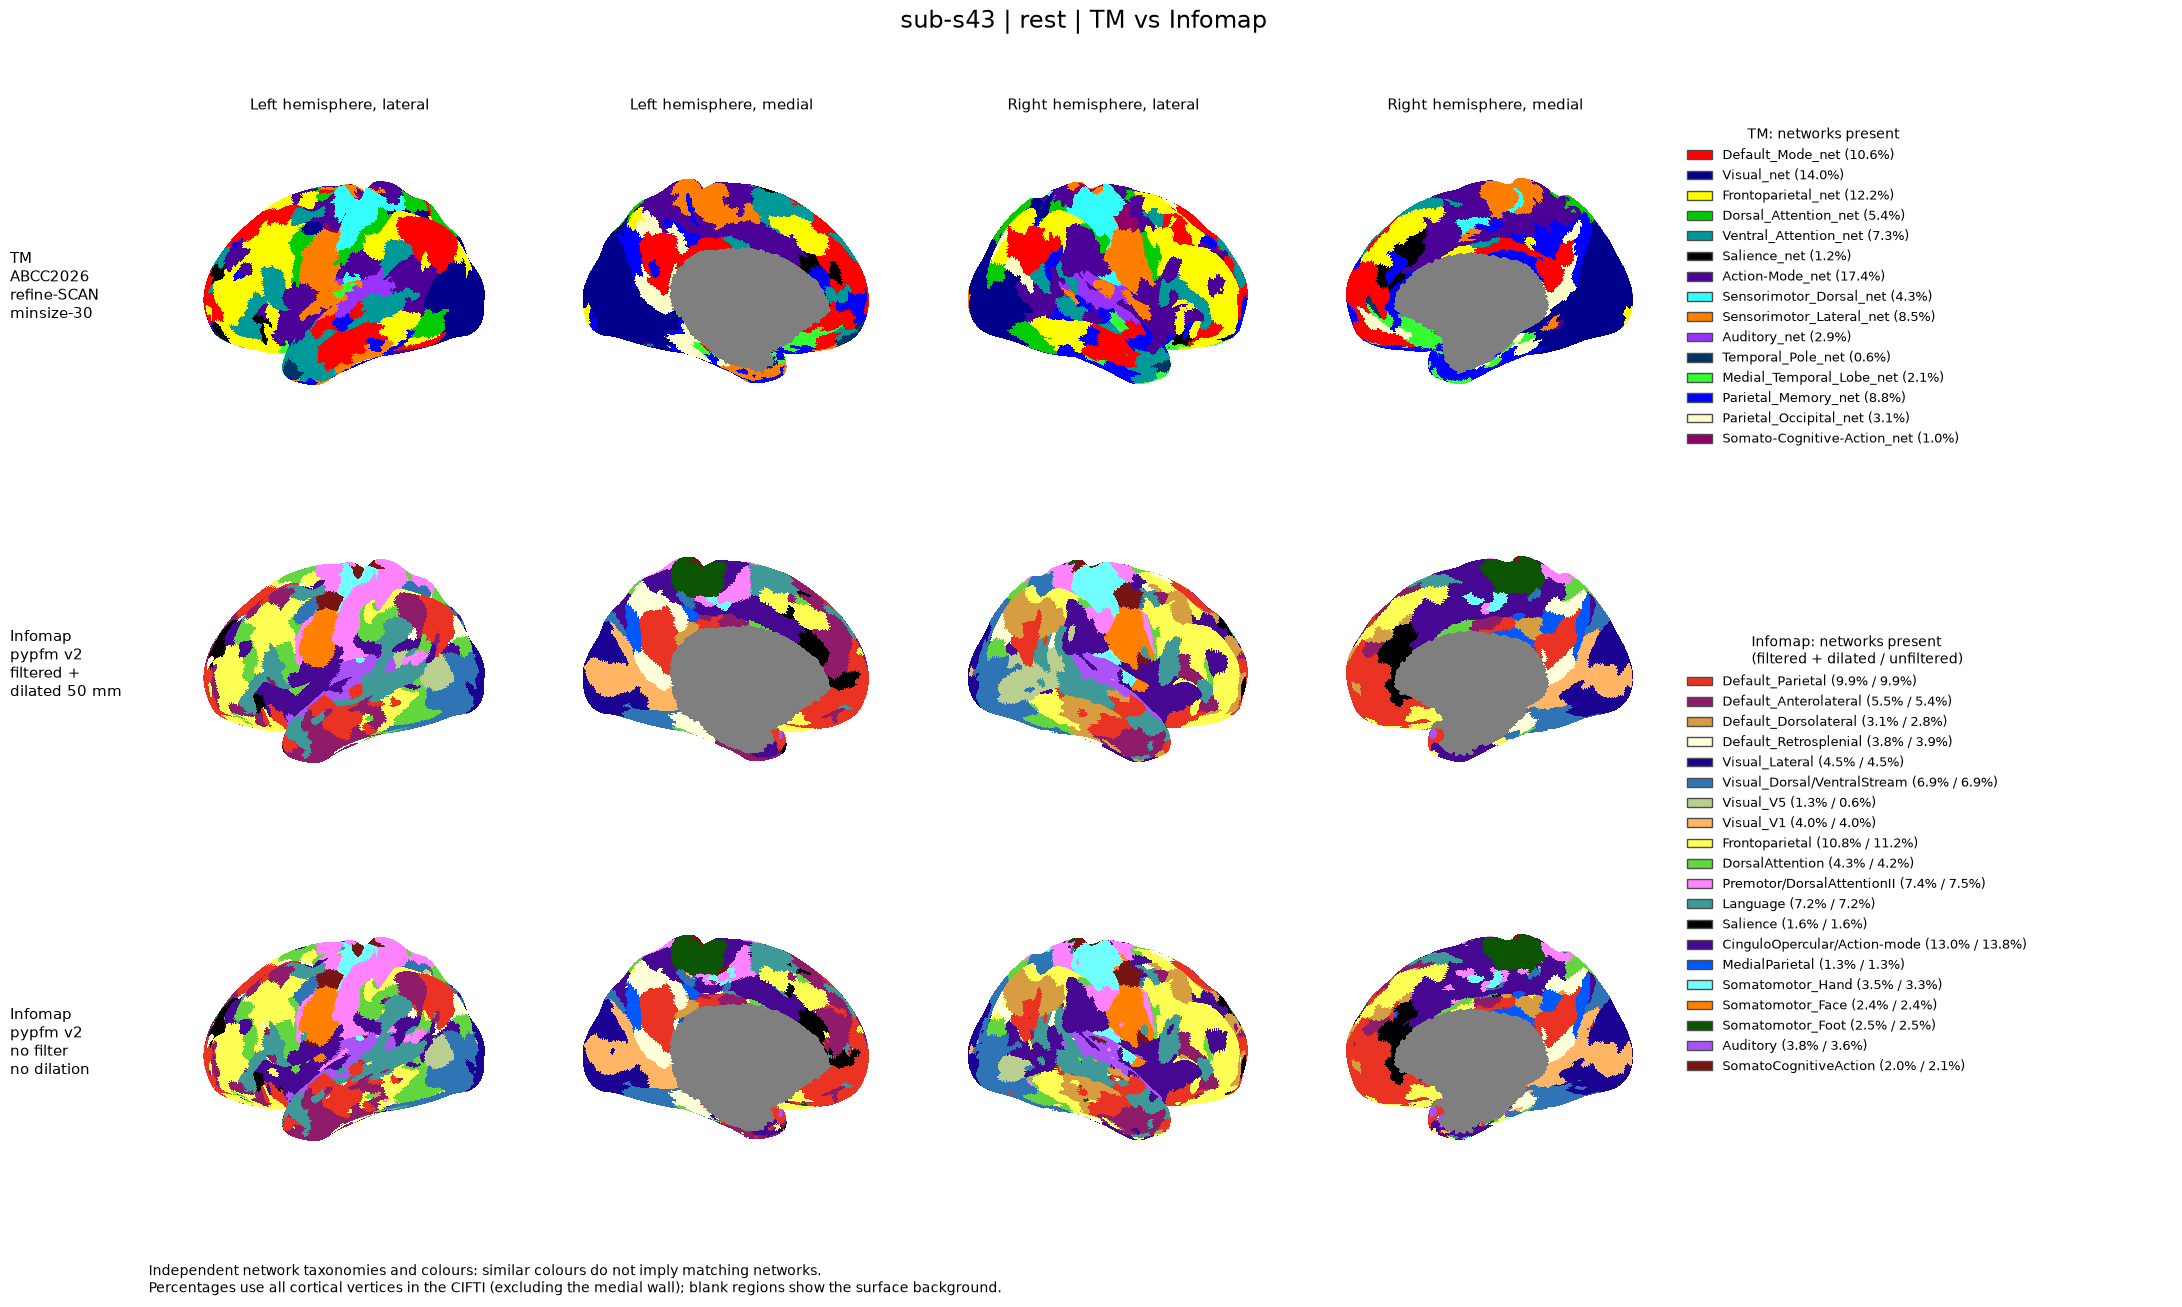

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s43_task-rest_TM-vs-Infomap.png


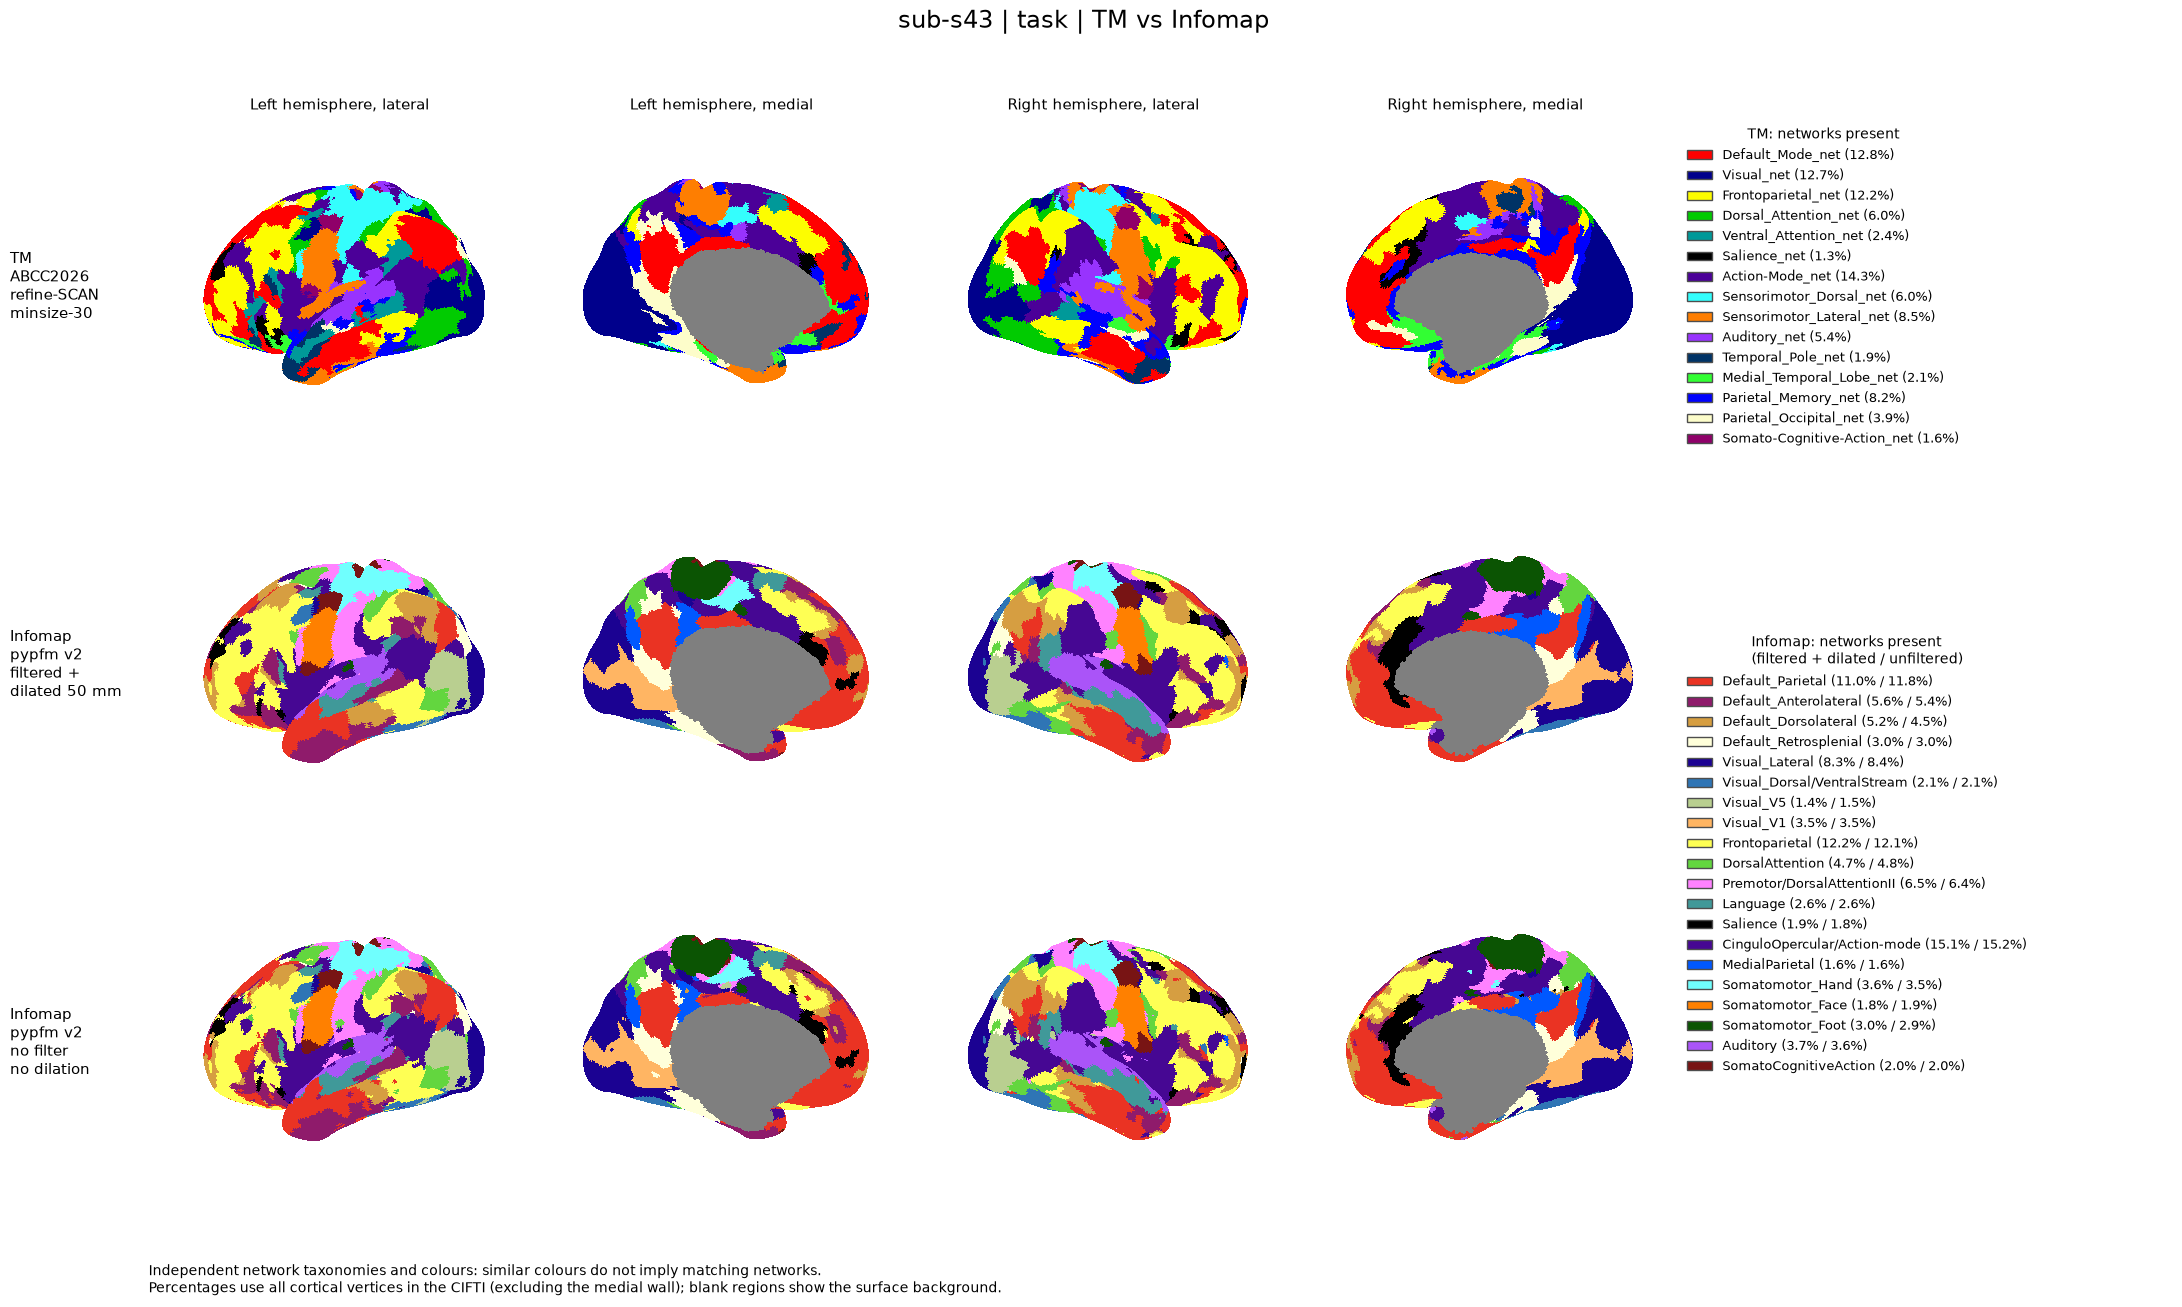

/oak/stanford/groups/russpold/users/grimsrud/projects/pfm_compare/analysis/tm_vs_infomap/30Sept2026_discovery_with_unfiltered/sub-s43_task-task_TM-vs-Infomap.png
Saved 10 comparisons


In [4]:
if not os.environ.get("SLURM_JOB_ID"):
    raise RuntimeError("Render in a Sherlock compute allocation.")
# Check all output names first, so reruns do not stop halfway through a batch.
if not OVERWRITE:
    conflicts = [OUTPUT_DIR / f"sub-{s}_task-{c}_TM-vs-Infomap.{ext}"
                 for s in SUBJECTS for c in CONDITIONS for ext in ("png", "json")
                 if (OUTPUT_DIR / f"sub-{s}_task-{c}_TM-vs-Infomap.{ext}").exists()]
    if conflicts:
        raise FileExistsError(f"Choose a new OUTPUT_DIR or set OVERWRITE=True: {conflicts}")
outputs = []
for subject in SUBJECTS:
    for condition in CONDITIONS:
        case = load_case(SETTINGS, subject, condition)
        fig, png = save_case(case, SETTINGS, OUTPUT_DIR, overwrite=OVERWRITE)
        display(fig)
        plt.close(fig)
        outputs.append(png)
        print(png)
print(f"Saved {len(outputs)} comparisons")


## 5. Review notes

Record qualitative observations by subject and condition. An all-subjects montage, harmonised taxonomy, and numerical comparisons remain outside this workflow.
